In [10]:
import os 
import sys
if '../src' not in sys.path:
    sys.path.append('../src')
from utilidades import mapeo_datos
import prince
import pandas as pd
from utilidades import planos_factoriales , grafico_planos_factoriales

In [11]:
mapeo_datos('../input/StudentsPerformance_with_headers.csv','../input/updated_students_performance_dataset.csv','../input/var_codes_meanings_student_performance.csv')

In [12]:
df = pd.read_csv('../input/updated_students_performance_dataset.csv')

In [13]:
df_personal = pd.concat([df.iloc[:,1:11],df.iloc[:,32:]],axis=1)
df_familiar = pd.concat([df.iloc[:,12:17],df.iloc[:,32:]],axis=1)
df_habitos = df.iloc[:,18:]

In [14]:
mca = prince.MCA(n_components=10)

In [15]:
mca = mca.fit(df.iloc[:,1:])

c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.



In [16]:
planos_personal = planos_factoriales(ACM=mca,data=df.iloc[:,1:],planos=[0,1])

In [17]:
grafico_planos_factoriales(planos_personal,mca.eigenvalues_summary,[0,1])

# modelo logit 

In [20]:
X = df.iloc[:,[1,2,3,4,5,6,7,10,11,12,15,16,17,20,22,23,24,25,26,29]]

In [22]:
Y = df.iloc[:,[32]]

In [24]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

encoder = OneHotEncoder(sparse=False)
X_encoded = encoder.fit_transform(X)
model = LogisticRegression(multi_class='multinomial',solver='lbfgs',max_iter=1000)
X_train, X_test, Y_train, Y_test = train_test_split(X_encoded,Y,test_size=0.25)

c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning:

`sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.

c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn

In [26]:
from utilidades import entrenamiento_modelo

In [27]:
model = entrenamiento_modelo(model,X_train,Y_train)

c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



In [28]:
from utilidades import prediccion_modelo

Y_pred = prediccion_modelo(model,X_test)

In [29]:
Y_pred

array(['DD', 'BB', 'DC', 'DD', 'BB', 'CC', 'DC', 'DC', 'DD', 'AA', 'BA',
       'CB', 'AA', 'CC', 'BB', 'CB', 'BB', 'DD', 'CC', 'DD', 'CC', 'CC',
       'BB', 'DC', 'DD', 'BB', 'BA', 'CC', 'AA', 'CC', 'AA', 'DD', 'DC',
       'DC', 'DC', 'DD', 'AA'], dtype=object)

In [41]:
from utilidades import evaluacion_modelo

ev = evaluacion_modelo(Y_test,Y_pred)

class_report:               precision    recall  f1-score   support

          AA       0.40      0.33      0.36         6
          BA       0.00      0.00      0.00         4
          BB       0.33      0.40      0.36         5
          CB       0.00      0.00      0.00         0
          CC       0.29      0.40      0.33         5
          DC       0.14      0.20      0.17         5
          DD       0.50      0.40      0.44        10
        Fail       0.00      0.00      0.00         2

    accuracy                           0.30        37
   macro avg       0.21      0.22      0.21        37
weighted avg       0.30      0.30      0.30        37



c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning:

is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.

c:\Users\bcriv\miniconda3\envs\pro_rs\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning:

is_spar

In [32]:
coef = model.coef_
feature_names = encoder.get_feature_names_out()
coef_df = pd.DataFrame(coef, columns=feature_names, index=model.classes_)
print(coef_df)

      Student_Age_18-21  Student_Age_22-25  Student_Age_above 26  Sex_female  \
AA             0.257252          -0.378290              0.121222   -0.981677   
BA            -0.101595           0.150416             -0.048558   -0.141185   
BB            -0.360501           0.507516             -0.147120    0.000048   
CB             0.159186           0.073155             -0.232239    0.154173   
CC            -0.074692          -0.277224              0.352296   -0.152001   
DC             0.367234          -0.118618             -0.249151    0.182373   
DD            -0.267432           0.036113              0.230746    0.124649   
Fail           0.020548           0.006932             -0.027197    0.813621   

      Sex_male  Graduated_high_school_type_other  \
AA    0.981861                          0.205022   
BA    0.141449                         -0.201999   
BB   -0.000153                          0.312831   
CB   -0.154070                         -0.189932   
CC    0.152381     

NameError: name 'plt' is not defined

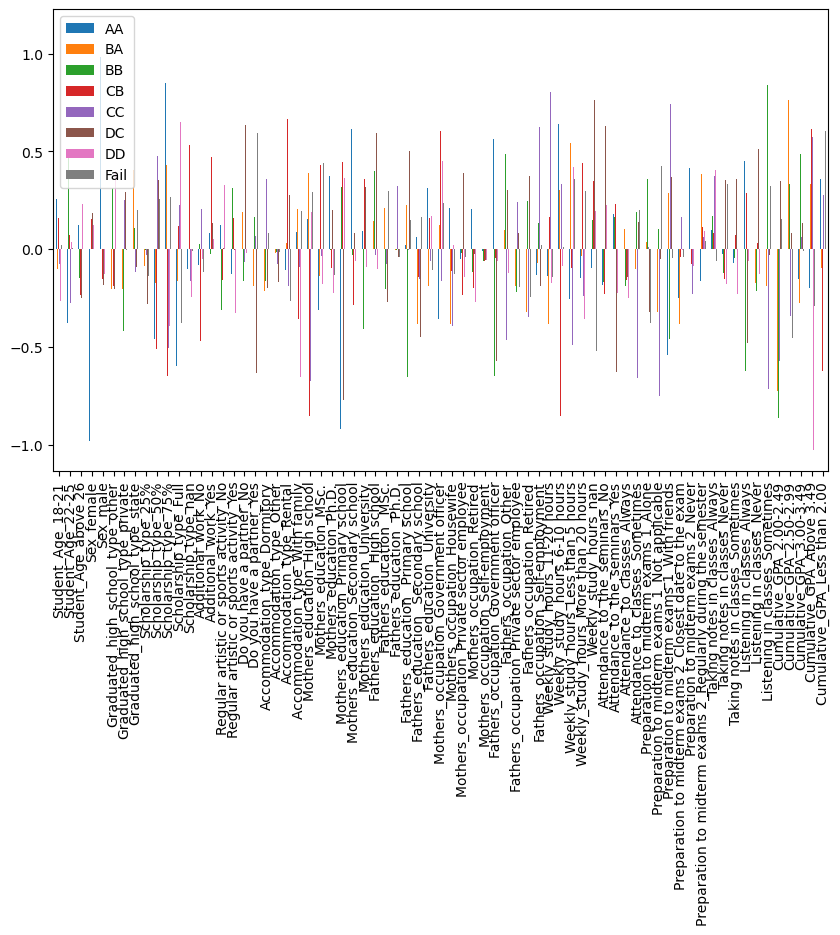

In [33]:
# Crear un gráfico de barras para cada categoría de la salida
coef_df.T.plot(kind='bar', figsize=(10, 6))

# Añadir título y etiquetas
plt.title('Coeficientes de la Regresión Logística Multiclase')
plt.ylabel('Valor del Coeficiente')
plt.xlabel('Variables Independientes')

# Mostrar la leyenda (las categorías de la variable dependiente)
plt.legend(title='Categoría de Respuesta', bbox_to_anchor=(1.05, 1), loc='upper left')

# Mostrar gráfico
plt.tight_layout()
plt.show()

In [38]:
def plot_coef_multiclass_logreg(model, feature_names, block_size=6):
    """
    Genera gráficos de coeficientes para un modelo de regresión logística multiclase, mostrando bloques de 4 variables a la vez.

    Parámetros:
    - model: modelo entrenado de LogisticRegression
    - feature_names: lista de nombres de las variables (por ejemplo, de OneHotEncoder)
    - block_size: número de variables por gráfico (por defecto 4)
    """
    # Obtener los coeficientes del modelo
    coef = model.coef_

    # Crear un DataFrame con los coeficientes
    coef_df = pd.DataFrame(coef, columns=feature_names, index=model.classes_)

    # Calcular cuántos bloques de gráficos necesitaremos
    num_features = len(feature_names)
    num_blocks = int(np.ceil(num_features / block_size))
    
    # Iterar sobre los bloques y generar gráficos
    for i in range(num_blocks):
        start_idx = i * block_size
        end_idx = min((i + 1) * block_size, num_features)

        # Seleccionar las variables de este bloque
        coef_block = coef_df.iloc[:, start_idx:end_idx]

        # Graficar el bloque
        coef_block.T.plot(kind='bar', figsize=(10, 6))

        # Añadir título y etiquetas
        plt.title(f'Coeficientes de la Regresión Logística (Bloque {i+1})')
        plt.ylabel('Valor del Coeficiente')
        plt.xlabel('Variables Independientes')

        # Mostrar la leyenda (categorías de la variable de respuesta)
        plt.legend(title='Categoría de Respuesta', bbox_to_anchor=(1.05, 1), loc='upper left')

        # Ajustar diseño
        plt.tight_layout()

        # Mostrar gráfico
        plt.show()


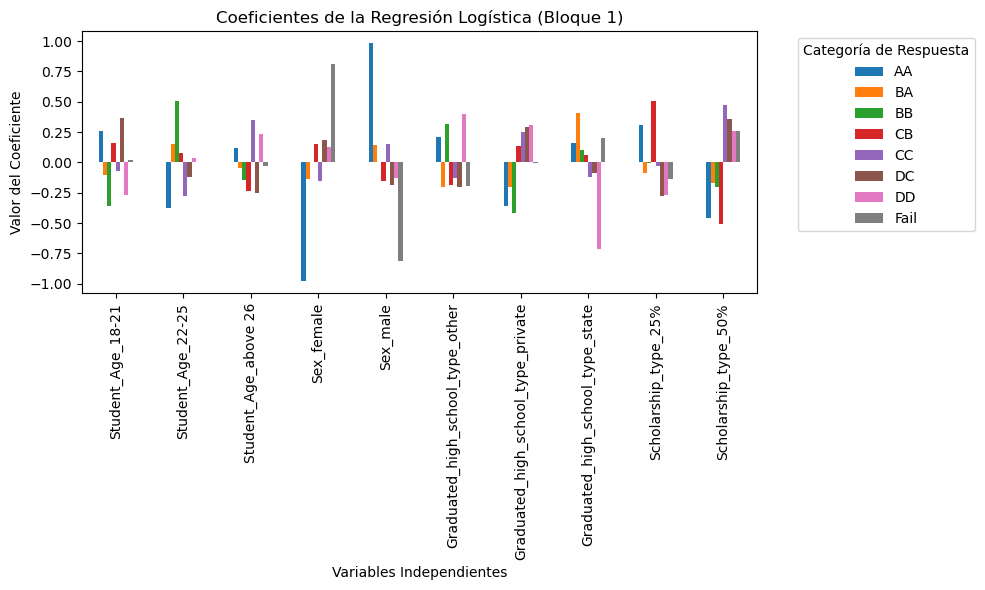

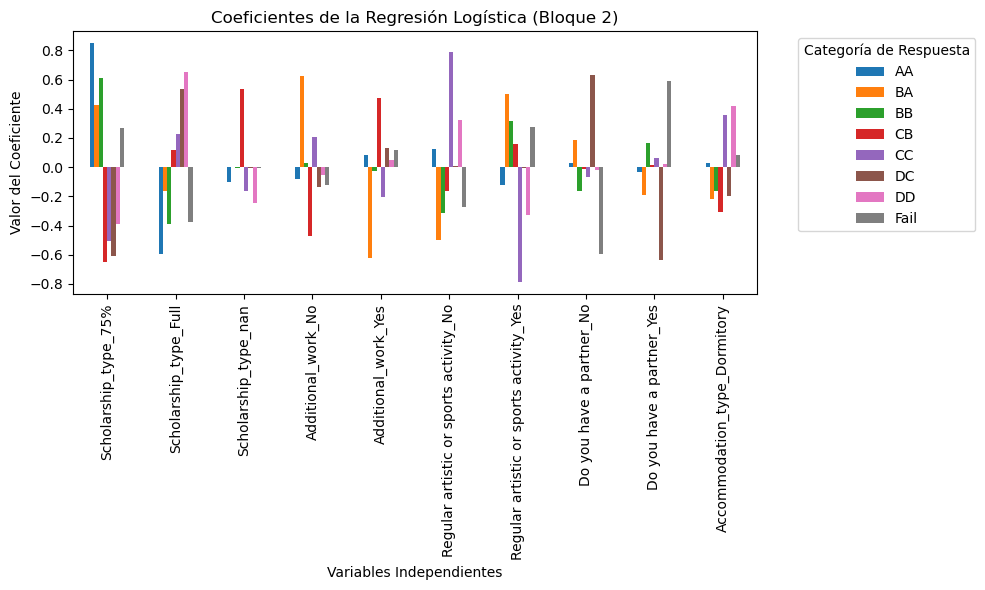

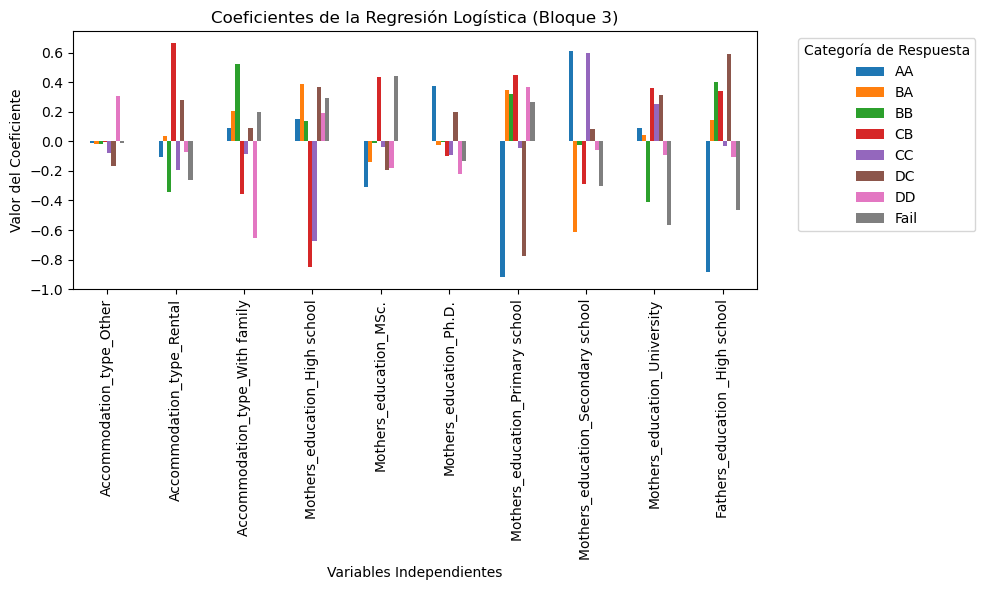

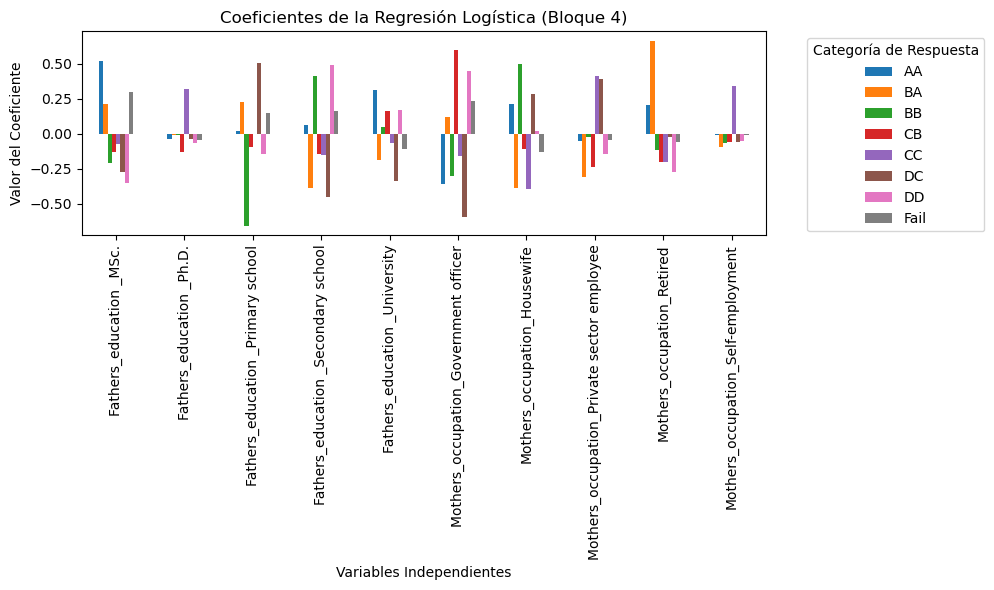

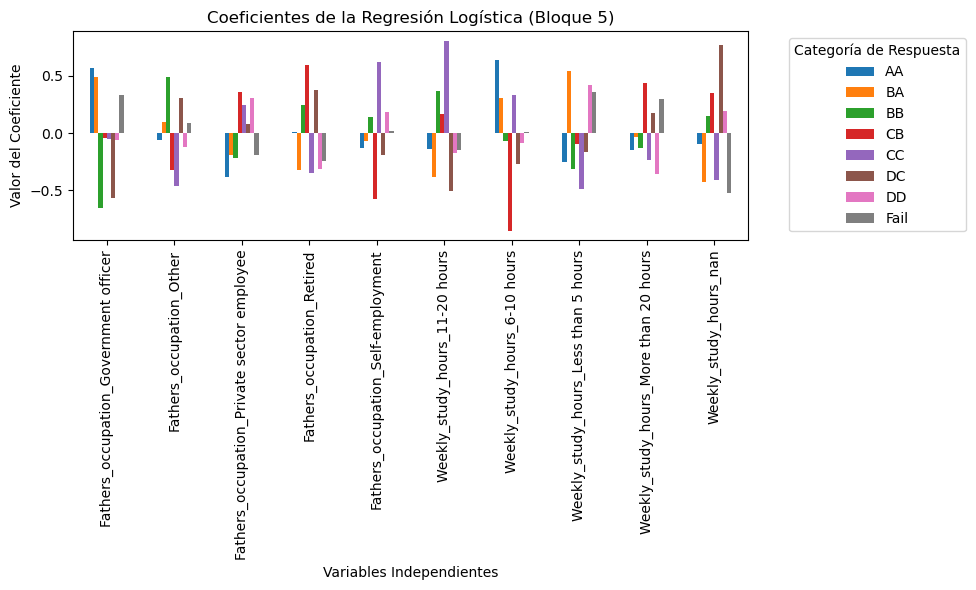

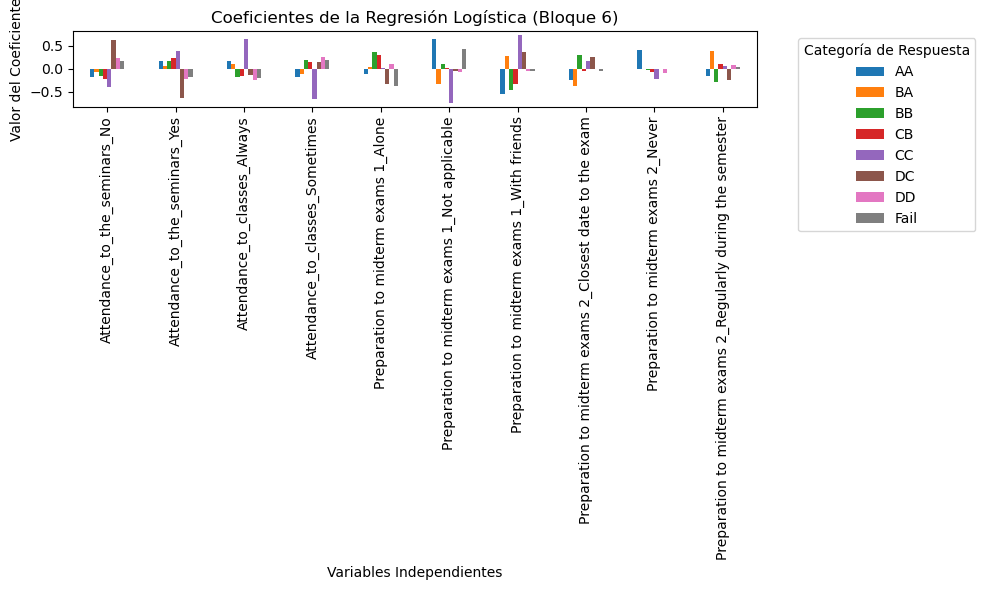

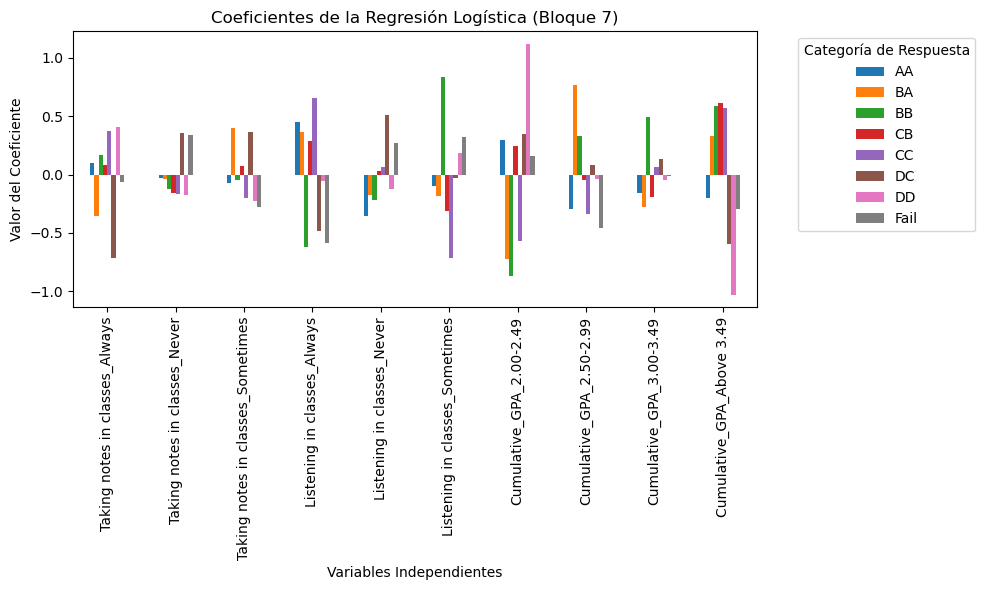

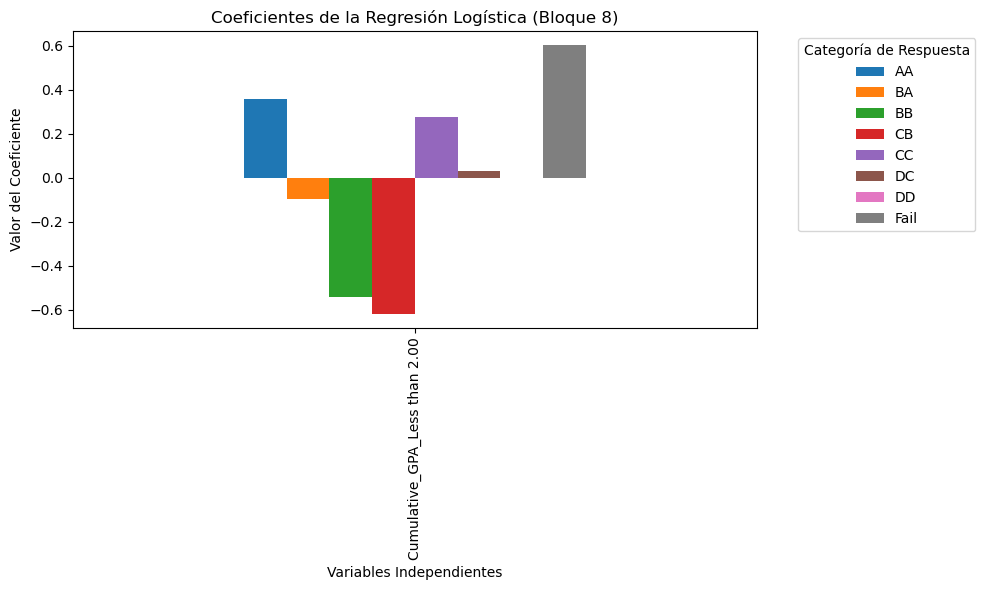

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
plot_coef_multiclass_logreg(model, feature_names, block_size=10)

In [46]:
from utilidades import grafico_de_matriz

grafico_de_matriz(ev[1],Y)

AttributeError: 'DataFrame' object has no attribute 'target_names'

<Figure size 800x600 with 0 Axes>

In [45]:
ev[1]

array([[2, 1, 1, 0, 2, 0, 0, 0],
       [0, 0, 2, 1, 0, 0, 1, 0],
       [0, 0, 2, 0, 2, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 2, 1, 1, 0],
       [1, 1, 0, 0, 0, 1, 2, 0],
       [0, 0, 1, 1, 1, 3, 4, 0],
       [1, 0, 0, 0, 0, 1, 0, 0]], dtype=int64)